# 회귀(regression) 디코더로 SO-101 팔 + AmazingHand 손 동시 구동 (공식 시뮬레이션)

`neural-to-output` 프로젝트와 독립적인 sandbox입니다 (`pyproject.toml`/`uv.lock` 미수정, 다른 노트북들과
같은 `examples` 의존성 그룹만 사용합니다).

**목표**: `06`번 노트북은 분류(classification) 디코더로 팔+손을 이산적인 행동(`"up"`/`"down"`,
`"grip"`/`"release"`)으로 구동했습니다. 이 노트북은 그 연속값(regression) 버전입니다 —
`03_finger_regression_amazinghand.ipynb`와 같은 합성 신호 방식을 그대로 유지하되, 손가락 굴곡도뿐
아니라 팔 관절까지 연속값으로 구동하도록 확장합니다. 디코더는 미리 정해둔 두 자세("내림"/"올림")
사이를 고르는 것이 아니라, 각 팔 관절의 각도(라디안)를 직접 예측합니다 — 그렇지 않으면 이산
분류를 회귀로 위장한 것일 뿐입니다.

역할 분리는 `06`번과 동일하되, 이산 라벨 대신 연속값을 다룹니다:

1. **`Decoder`** — 순수 회귀 모델. 합성 신호를 보고 손가락 4개의 굴곡도(0~1)와 팔 관절 2개
   (`shoulder_lift`, `elbow_flex`)의 각도(라디안), 총 6개의 연속값을 그대로 반환합니다.
2. **`Command`** — 디코더가 반환한 flat한 6개 값 dict를 부위별(팔/손)로 묶고,
   `ActionType.JOINT_ABSOLUTE`로 태그해서 각 값이 raw 관절 목표값임을 표시합니다.
3. **`n2o.robot.Part`** — 그 태그된 raw 값을 실제 목표값으로 바꿉니다: 팔 쪽은 이미 라디안
   단위인 관절 각도를 그대로 쓰고, 손 쪽은 0~1 굴곡도를 실제 라디안 값으로 변환합니다 (`03`번과
   동일한 스케일링).

**중요한 차이점 하나**: 상용(shipped) `n2o.robot.arm.so101.SO101Arm`/`n2o.robot.hand.amazing_hand.AmazingHand`는
`goal(cmd)`가 고정된 `GESTURES` 딕셔너리(`"up"`/`"down"`, `"grip"`/`"release"`, ...)를 이름으로 조회할
뿐입니다 — `ActionType`으로 태그된 연속값 커맨드는 아직 어떤 상용 `Part`에도 연결되어 있지 않습니다
(`SO101Arm`/`ROADMAP.md`의 IK 관련 메모 참고: "`Command.translate()`가 아직 `(ActionType, {...})` 커맨드를
만들지 않아서 연결할 대상이 없음"). 그래서 이 노트북은 `06`번의 `SO101Arm`/`AmazingHand`를 그대로
재사용하는 대신, 이 노트북 전용 `Part` 구현(`ContinuousSO101Arm`/`ContinuousAmazingHand`)을 직접
정의합니다 — `goal()`은 `(ActionType.JOINT_ABSOLUTE, {...})`를 목표값으로 변환하는 순수 계산만 하고,
`n2o.robot.simulation.Simulator`가 그 목표값을 MuJoCo에 반영하는 건 `06`번과 동일합니다.

로봇 모델은 `06`번과 동일하게 공식 CAD 출처를 그대로 사용합니다 (`assets/so101/`,
`assets/amazing_hand_right/`, 이제 `n2o.robot.simulation`이 내부적으로 소유). 이 노트북도
**시뮬레이션만** 다루며, 실제 하드웨어에는 어떤 명령도 보내지 않습니다.

In [ ]:
import math
import os

os.environ.setdefault(
    "MUJOCO_GL", "egl"
)  # 디스플레이 없는 환경에서도 오프스크린 렌더링

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import torch

from n2o import N2O
from n2o.command import ActionType, Command, CommandConfig
from n2o.decoder import DecoderConfig, DecoderType, FeatureType, Regression
from n2o.robot import Part
from n2o.robot.simulation import Simulator

ARM_JOINTS = [
    "shoulder_pan",
    "shoulder_lift",
    "elbow_flex",
    "wrist_flex",
    "wrist_roll",
    "gripper",
]
FINGERS = ["finger1", "finger2", "finger3", "finger4"]
ARM_REGRESSION_JOINTS = ["shoulder_lift", "elbow_flex"]
JOINT_RANGE = {
    "shoulder_lift": (-0.6, 0.6),
    "elbow_flex": (-0.3, 0.3),
}
TARGET_KEYS = FINGERS + ARM_REGRESSION_JOINTS

## 1. 합성 신호 생성

`03`번 노트북과 같은 방식입니다: 실제 EEG+운동학을 동시에 기록한 공개 데이터셋은 이 프로젝트의
`examples` 의존성 그룹에 포함하기엔 너무 크므로, 목표값과 상관된 **합성(synthetic) 신호**로
회귀 디코더의 입출력 shape과 학습/추론 흐름을 보여줍니다. 채널 0~3은 각 손가락 굴곡도에 비례한
주파수로, 신호 전체의 진폭은 `shoulder_lift`(정규화된 값)에 비례하도록 만들어서, 최소한 "신호와
타깃이 상관되어 있어 학습이 가능하다"는 성질만 갖도록 했습니다. `shoulder_lift`/`elbow_flex`는
`04`번의 두 자세("내림"/"올림")가 아니라, 그 자세들이 쓰던 것과 같은 실제 가동범위 안에서 뽑은
**연속값**입니다.

In [2]:
RNG = np.random.default_rng(0)  # 재현성

N_CHANS = 8
N_TIMES = 250  # 1s @ 250Hz 가정


def make_synthetic_sample():
    """손가락 굴곡도 4개(0~1) + 팔 관절각 2개(라디안)와 상관된 합성 신호 한 개를 만듭니다.

    실제 프로젝트에서는 이 함수 대신 `n2o.signal.dataset.DatasetLoader`의 실제 구현의
    `read()`가 이 자리를 대체합니다.
    """
    finger_flex = RNG.uniform(0, 1, size=len(FINGERS))
    shoulder_lift = RNG.uniform(*JOINT_RANGE["shoulder_lift"])
    elbow_flex = RNG.uniform(*JOINT_RANGE["elbow_flex"])
    targets = np.concatenate([finger_flex, [shoulder_lift, elbow_flex]]).astype(
        np.float32
    )

    # 신호 진폭 변조용으로만 쓰는 0~1 정규화값 (실제 타깃은 위 라디안 값 그대로임)
    shoulder_lift_norm = (shoulder_lift - JOINT_RANGE["shoulder_lift"][0]) / (
        JOINT_RANGE["shoulder_lift"][1] - JOINT_RANGE["shoulder_lift"][0]
    )
    t = np.linspace(0, 1, N_TIMES, endpoint=False)
    amplitude = 0.5 + 1.5 * shoulder_lift_norm
    signal = np.stack(
        [
            amplitude * np.sin(2 * np.pi * (5 + 3 * finger_flex[ch % len(FINGERS)]) * t)
            + RNG.normal(0, 0.3, N_TIMES)
            for ch in range(N_CHANS)
        ]
    )
    return signal.astype(np.float32), targets


X0, y0 = make_synthetic_sample()
print("합성 신호 shape (n_chans, n_times):", X0.shape)
print("targets:", dict(zip(TARGET_KEYS, y0.round(2))))

합성 신호 shape (n_chans, n_times): (8, 250)
targets: {'finger1': np.float32(0.64), 'finger2': np.float32(0.27), 'finger3': np.float32(0.04), 'finger4': np.float32(0.02), 'shoulder_lift': np.float32(0.38), 'elbow_flex': np.float32(0.25)}


## 2. 학습/검증용 합성 데이터셋 만들기

`make_synthetic_sample()`을 여러 번 호출해서 작은 데이터셋을 만들고 train/valid로 나눕니다.

In [3]:
N_SAMPLES = 200
X_all = np.zeros((N_SAMPLES, N_CHANS, N_TIMES), dtype=np.float32)
y_all = np.zeros((N_SAMPLES, len(TARGET_KEYS)), dtype=np.float32)
for i in range(N_SAMPLES):
    X_all[i], y_all[i] = make_synthetic_sample()

n_train = 160
X_train, y_train = X_all[:n_train], y_all[:n_train]
X_valid, y_valid = X_all[n_train:], y_all[n_train:]
print(f"train samples: {len(X_train)}, valid samples: {len(X_valid)}")

train samples: 160, valid samples: 40


## 3. 연속값 전용 `Part` + `Simulator`: 공식 CAD 시뮬레이션

`06`번과 동일한 시뮬레이션 자산(`n2o.robot.simulation`이 내부적으로 소유)을 사용하지만, 상용
`SO101Arm`/`AmazingHand`는 `goal(cmd)`가 고정된 `GESTURES` 이름 조회만 지원하므로(위 인트로 참고) 이
노트북에서는 직접 쓸 수 없습니다. 대신 이 노트북 전용 `n2o.robot.Part` 구현을 정의합니다 —
`ContinuousSO101Arm.goal()`은 `Command`가 `(ActionType.JOINT_ABSOLUTE, pose)`로 넘긴 관절 각도(라디안)를
`Simulator`가 기대하는 목표값 형태(도(degree) 단위 딕셔너리 — `Simulator`가 내부적으로 다시 라디안으로
변환하므로, 라디안으로 온 예측값을 `math.degrees()`로 왕복 변환합니다)로 바꾸고, 예측하지 않은 관절은
그대로 둡니다. `ContinuousAmazingHand.goal()`은 0~1 굴곡도를 실제 라디안 값으로 변환합니다(모터2/외전
축은 항상 중립). 두 `Part` 모두 `move()`는 구현하지 않습니다 — 이 노트북은 시뮬레이션만 다루므로 실제
하드웨어를 구동할 일이 없습니다.

In [ ]:
class ContinuousSO101Arm(Part):
    """이 노트북 전용 `n2o.robot.Part`. 상용 `n2o.robot.arm.so101.SO101Arm`은 고정된
    `GESTURES`(`"up"`/`"down"`) 이름만 받아들이고 연속값/`ActionType` 커맨드는 아직
    연결돼 있지 않으므로(ROADMAP.md 참고), 회귀 디코더가 예측한 관절각(라디안)을 그대로
    시뮬레이션에 흘려보내려면 이렇게 직접 정의합니다.

    `goal()`은 `Simulator.drive("arm", ...)`이 기대하는 도(degree) 단위 딕셔너리를
    반환하는 순수 계산입니다 -- `Simulator`가 내부적으로 다시 라디안으로 변환하므로,
    이미 라디안인 예측값을 `math.degrees()`로 왕복 변환해서 넘깁니다. 예측하지 않은
    관절(`wrist_flex` 등)은 아예 딕셔너리에 넣지 않습니다 -- `Simulator`가 현재 ctrl
    값을 그대로 유지합니다.
    """

    def goal(self, cmd):
        _action_type, pose_rad = cmd
        return {joint: math.degrees(value) for joint, value in pose_rad.items()}

    def move(self, cmd):
        raise NotImplementedError(
            "이 노트북은 시뮬레이션만 다룹니다 -- 실제 하드웨어는 "
            "n2o.robot.arm.so101.SO101Arm.move()를 쓰세요"
        )

In [ ]:
FLEXION_TO_RAD = 1.4  # 02/03번 노트북과 동일한 최대 굴곡 각도


class ContinuousAmazingHand(Part):
    """이 노트북 전용 `n2o.robot.Part`. 상용 `n2o.robot.hand.amazing_hand.AmazingHand`도
    마찬가지로 고정된 `GESTURES` 이름만 받아들이므로, `Command`가
    `(ActionType.JOINT_ABSOLUTE, flexion)`으로 넘긴 손가락별 0~1 굴곡도를 실제 라디안
    값으로 변환하는 `goal()`을 직접 정의합니다 (모터2/외전 축은 항상 중립)."""

    def goal(self, cmd):
        _action_type, flexion = cmd
        target = [0.0] * 8
        for i, finger in enumerate(FINGERS):
            target[2 * i] = flexion[finger] * FLEXION_TO_RAD  # motor1 = flexion
            # motor2 (외전)은 중립(0)으로 유지
        return target

    def move(self, cmd):
        raise NotImplementedError(
            "이 노트북은 시뮬레이션만 다룹니다 -- 실제 하드웨어는 "
            "n2o.robot.hand.amazing_hand.AmazingHand.move()를 쓰세요"
        )

In [ ]:
sim = Simulator()

arm_part = ContinuousSO101Arm()
sample_pose = {"shoulder_lift": 0.3, "elbow_flex": -0.15}  # 라디안 (임의 예시값)
target = arm_part.goal((ActionType.JOINT_ABSOLUTE, sample_pose))
print("ContinuousSO101Arm.goal(...) ->", target)

sim.drive("arm", target)
plt.figure(figsize=(5, 4))
plt.imshow(sim.render("arm"))
plt.axis("off")
plt.title(f"SO-101 arm (MuJoCo sim) -> {sample_pose}")
plt.show()

hand_part = ContinuousAmazingHand()
sample_flexion = {"finger1": 0.8, "finger2": 0.3, "finger3": 0.1, "finger4": 0.5}
target = hand_part.goal((ActionType.JOINT_ABSOLUTE, sample_flexion))
print("ContinuousAmazingHand.goal(...) ->", target)

sim.drive("hand", target)
plt.figure(figsize=(5, 4))
plt.imshow(sim.render("hand"))
plt.axis("off")
plt.title(f"AmazingHand (MuJoCo sim) -> {sample_flexion}")
plt.show()

## 4. `Decoder` 서브클래스: 순수 회귀 모델

작은 1D-conv 회귀 모델을 `n2o.decoder.Regression`으로 감싸서, `decode(signal)`이
`{"finger1": 0.0-1.0, ..., "shoulder_lift": radians, "elbow_flex": radians}` 형태의 연속값 6개를
그대로 반환하도록 합니다 — 그 값을 팔/손이 어떻게 나눠 쓸지는 전혀 모릅니다. `Decoder`를 직접
상속하지 않는 이유는 `Regression`이 연속값 타깃 디코더용 `preprocess()`/`window()`를 이미
구현해두고 있어서입니다. 손가락 굴곡도 4개는 sigmoid로 [0, 1] 범위로 제한하고, 팔 관절각 2개는
실제 라디안 단위 그대로(별도 활성함수 없이) 출력합니다 — 미리 정해둔 두 자세 중 하나를 고르는 것이
아니라 관절각 자체를 직접 회귀합니다.

In [ ]:
class ArmHandFlexionNet(torch.nn.Module):
    def __init__(self, n_chans, n_times, n_fingers, n_arm_joints):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv1d(n_chans, 16, kernel_size=9, padding=4),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
        )
        self.flatten = torch.nn.Flatten()
        self.finger_head = torch.nn.Sequential(
            torch.nn.Linear(16, n_fingers), torch.nn.Sigmoid()
        )
        self.arm_head = torch.nn.Linear(16, n_arm_joints)  # 라디안 값, 활성함수 없음

    def forward(self, x):
        features = self.flatten(self.conv(x))
        return torch.cat([self.finger_head(features), self.arm_head(features)], dim=-1)


class ArmHandFlexionDecoder(Regression):
    """손가락별 굴곡도(0~1) + 팔 관절각(라디안)을 함께 예측하는 순수 회귀 디코더."""

    output_type = FeatureType.ACTION

    def __init__(self, n_chans, n_times):
        self.input_spec = {"n_chans": n_chans, "n_times": n_times}
        self.output_spec = {
            **{finger: "flexion in [0, 1]" for finger in FINGERS},
            **{joint: "radians" for joint in ARM_REGRESSION_JOINTS},
        }
        self.config = DecoderConfig(type=DecoderType.REGRESSION)
        self.model = ArmHandFlexionNet(
            n_chans,
            n_times,
            n_fingers=len(FINGERS),
            n_arm_joints=len(ARM_REGRESSION_JOINTS),
        )

    def decode(self, signal):
        self.model.eval()
        with torch.no_grad():
            x = torch.tensor(signal).unsqueeze(0).float()
            values = self.model(x)[0]
        return {key: float(v) for key, v in zip(TARGET_KEYS, values)}


decoder = ArmHandFlexionDecoder(n_chans=N_CHANS, n_times=N_TIMES)
print(decoder.model)

## 5. `Command`: 연속값을 팔+손 목표로 매핑

디코더가 반환하는 flat한 6개 값(`decoded_signal`)을 부위별(팔/손)로 묶고, 각 값이 이미 자기
설명적인 이름이 아니라 raw 회귀 값이라는 것을 나타내기 위해 `ActionType.JOINT_ABSOLUTE`로
태그합니다.

In [7]:
class ArmHandFlexionCommand(Command):
    """decoded_signal의 6개 값을 부위별로 묶고, raw 관절 목표값임을 `ActionType.JOINT_ABSOLUTE`로
    태그합니다."""

    def translate(self, decoder, decoded_signal):
        arm_pose = {joint: decoded_signal[joint] for joint in ARM_REGRESSION_JOINTS}
        hand_flexion = {finger: decoded_signal[finger] for finger in FINGERS}
        return {
            "type": decoder.config.type,
            "arm": (ActionType.JOINT_ABSOLUTE, arm_pose),
            "hand": (ActionType.JOINT_ABSOLUTE, hand_flexion),
        }


command = ArmHandFlexionCommand()

## 6. 학습 sanity check (`MSELoss`)

분류가 아니라 회귀이므로 `CrossEntropyLoss` 대신 `MSELoss`를 씁니다. 합성 데이터 160개 전체를 반복
학습시켜서 loss가 떨어지는지만 확인합니다.

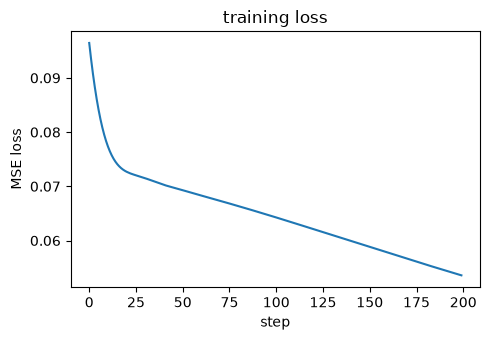

마지막 step MSE: 0.0536


In [8]:
decoder.model.train()
opt = torch.optim.Adam(decoder.model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float()

n_steps = 200
loss_history = []
for step in range(n_steps):
    opt.zero_grad()
    pred = decoder.model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    opt.step()
    loss_history.append(loss.item())

plt.figure(figsize=(5, 3.5))
plt.plot(loss_history)
plt.xlabel("step")
plt.ylabel("MSE loss")
plt.title("training loss")
plt.tight_layout()
plt.show()

print(f"마지막 step MSE: {loss_history[-1]:.4f}")

## 7. `N2O` 파이프라인으로 검증 샘플 구동

학습에 쓰지 않은 검증 세트에서 샘플 몇 개를 뽑아 `N2O`가 실제로 signal -> decoder(연속값) ->
`ContinuousCommand`(팔+손 목표) -> robot.arm/hand까지 전체 파이프라인을 통과시키는지 확인합니다.

In [ ]:
class ValidationSampleSignal:
    """검증 세트의 합성 신호를 순서대로 돌려주는 signal 소스."""

    def __init__(self, samples):
        self.samples = samples
        self.i = 0

    def read(self):
        sample = self.samples[self.i]
        self.i += 1
        return sample


N_VALID_SAMPLES = 3
samples = [X_valid[i] for i in range(N_VALID_SAMPLES)]
true_targets = [
    dict(zip(TARGET_KEYS, y_valid[i].round(2))) for i in range(N_VALID_SAMPLES)
]

n2o = N2O()
n2o.signal = ValidationSampleSignal(samples)
n2o.decoder = decoder
n2o.command = command
n2o.robot.arm = ContinuousSO101Arm()
n2o.robot.hand = ContinuousAmazingHand()

n2o.command_config = CommandConfig()
print(n2o.command_config.verify_report(n2o))

In [ ]:
for i in range(N_VALID_SAMPLES):
    predicted = decoder(samples[i])
    print(f"--- 검증 샘플 {i + 1}/{N_VALID_SAMPLES} ---")
    print(f"  실제 타깃: { {k: round(v, 2) for k, v in true_targets[i].items()} }")
    print(f"  예측값:   { {k: round(v, 2) for k, v in predicted.items()} }")
    n2o.run(controller="simulation")

## 8. 가동범위 확인

팔의 각 관절이 실제로 `assets/so101/mjcf`에 박혀 있는 공식 가동범위 안에 있었는지 확인합니다.

In [ ]:
print("관절별 가동범위 확인 (공식 벤더 값 기준):")
# n2o.robot.arm(ContinuousSO101Arm)은 goal()만 순수 계산하고 MuJoCo 상태는 갖지 않으므로,
# 실제 물리 상태는 n2o.run(controller="simulation")이 자동으로 만든 Simulator가 내부에
# 들고 있습니다. Simulator는 그 model/data를 공개 API로 노출하지 않으므로(_arm이 비공개
# 속성), 아래는 실행 후 사후 확인용으로만 그 내부를 직접 들여다봅니다.
arm_model = n2o.robot.simulator._arm
for joint in ARM_JOINTS:
    joint_id = mujoco.mj_name2id(arm_model.model, mujoco.mjtObj.mjOBJ_JOINT, joint)
    lo, hi = arm_model.model.jnt_range[joint_id]
    value = arm_model.data.qpos[joint_id]
    status = "OK" if lo - 1e-6 <= value <= hi + 1e-6 else "범위 초과"
    print(
        f"  {joint:14s}: {value:6.3f} rad   (공식 범위 [{lo:6.3f}, {hi:6.3f}])   {status}"
    )

## 정리

- `Regression`(`ArmHandFlexionDecoder`)은 순수 회귀 모델로만 남았습니다 — 손가락 굴곡도 4개(0~1)와
  팔 관절각(`shoulder_lift`, `elbow_flex`, 라디안) 2개, 총 6개의 연속값을 그대로 반환할 뿐, 팔/손이
  그 값을 어떻게 나눠 쓸지는 전혀 모릅니다. 미리 정해둔 두 자세 중 하나를 고르는 게 아니라 관절각
  자체를 직접 회귀하므로, 이산 분류를 회귀로 위장한 것이 아닙니다.
  `config.type = DecoderType.REGRESSION`으로 표시했습니다.
- `ArmHandFlexionCommand`가 그 flat한 6개 값을 부위별로 묶고, raw 회귀 값임을 나타내는
  `ActionType.JOINT_ABSOLUTE`로 태그해서 `Robot.router()`에 넘깁니다.
- 상용 `n2o.robot.arm.so101.SO101Arm`/`n2o.robot.hand.amazing_hand.AmazingHand`는 `goal(cmd)`가 고정된
  `GESTURES` 이름 조회만 지원하고 `ActionType`으로 태그된 연속값 커맨드는 아직 어떤 상용 `Part`에도
  연결돼 있지 않으므로(`ROADMAP.md` 참고), 이 노트북은 대신 `ContinuousSO101Arm`/
  `ContinuousAmazingHand`라는 노트북 전용 `n2o.robot.Part` 구현을 정의했습니다 — 팔 쪽은 이미 라디안
  단위인 관절각을 `Simulator`가 기대하는 도(degree) 딕셔너리로 왕복 변환하고(예측하지 않은 관절은
  건드리지 않음), 손 쪽은 0~1 굴곡도를 라디안으로 스케일링합니다. 두 `Part` 모두 `move()`는 구현하지
  않았습니다 — 이 노트북은 시뮬레이션만 다루므로 실제 하드웨어를 구동할 일이 없습니다.
- `n2o.robot.simulation.Simulator`가 그 `goal()` 결과를 받아 MuJoCo에 반영합니다 —
  `n2o.run(controller="simulation")` 한 줄이면 `Simulator`를 자동으로 만들고(`robot.simulator`),
  검증 세트의 합성 신호들을 흘려보내 파이프라인이 예외 없이 끝까지 동작하는 것을 확인했습니다.
  팔의 모든 관절이 `TheRobotStudio/SO-ARM100`의 공식 가동범위 안에 있음도 확인했습니다 (MuJoCo 위치
  액추에이터가 자동으로 clamp).
- `06`번(이산 분류)과 이 노트북(연속 회귀)은 `Decoder`/`Command`/`Part`/`Simulator` 구조를 똑같이
  공유합니다 — 값이 이미 자기 설명적인 이름(`"grip"`)이냐 raw 회귀 값(`ActionType`으로 태그된
  튜플)이냐에 따라 `Command.translate()`의 구현만 달라지는 게 원래 의도이지만, 현재는 상용 `Part`
  구현(`SO101Arm`/`AmazingHand`)이 후자를 아직 지원하지 않아 이 노트북은 자체 `Part`를 따로 정의해야
  했습니다 — `ActionType` 커맨드가 상용 `Part`에 연결되면(`ROADMAP.md`) 이 노트북 전용 클래스들은
  지울 수 있을 것입니다.